# pointplot_simdiff.py

## Purpose
Analyze `prolific_pairwise.csv` to see how often charA is chosen
when it is always the more-similar character.
We plot the probability of choosing charA (`chosen=1`) as a function
of `simDiff` (0..3) using Seaborn’s new syntax for confidence intervals.

## Data
We load `data/preprocessed/prolific_pairwise.csv` and subset to "simDiff" > 0.
- `chosen` ∈ [0,1]  
- `simDiff` ∈ [0,1,2,3]

## Output
A single PNG in `figures/`:
- `pointplot_chosen_vs_simDiff.png` showing mean `chosen` by `simDiff` with 95% CI.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from notebooks.helpers import bootstrap_ci
import os

## 1. Load Data

In [2]:
DATA_PATH = "data/preprocessed/attribute_judgments.csv"
df = pd.read_csv(DATA_PATH)
df = df[df["simDiff"] > 0].copy() # Exclude simDiff<=0 for clarity
print(f"Loaded {len(df)} rows from {DATA_PATH}")

# Display a snippet for confirmation
df.head()

Loaded 1286 rows from data/preprocessed/attribute_judgments.csv


,subject,task_type,task_ordering,condition,subject_race,subject_age,subject_gender,character,opponent,simChar,...,UnusualDiff,WarmChar,WarmOpp,WarmDiff,CompetentChar,CompetentOpp,CompetentDiff,SocialStatusChar,SocialStatusOpp,SocialStatusDiff
0,1,choice,0,Threatening,Black,30,woman,464,81,2,...,0.807152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,choice,0,Threatening,Black,30,woman,280,487,3,...,-1.127059,NaN,2.882353,NaN,NaN,2.970588,NaN,NaN,2.647059,NaN
4,1,choice,0,Threatening,Black,30,woman,562,692,1,...,0.685771,4.521739,NaN,NaN,4.869565,NaN,NaN,4.956522,NaN,NaN
6,1,choice,0,Threatening,Black,30,woman,270,81,3,...,0.733078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,choice,0,Threatening,Black,30,woman,280,562,3,...,-0.393043,NaN,4.521739,NaN,NaN,4.869565,NaN,NaN,4.956522,NaN


## 2. Plot Probability of Choosing charA vs. simDiff
We'll use Seaborn's `pointplot` with the recommended `errorbar=('ci',95)` syntax
to avoid deprecation warnings.

Plot saved to attribute_figures/pointplot_chosen_vs_simDiff.png


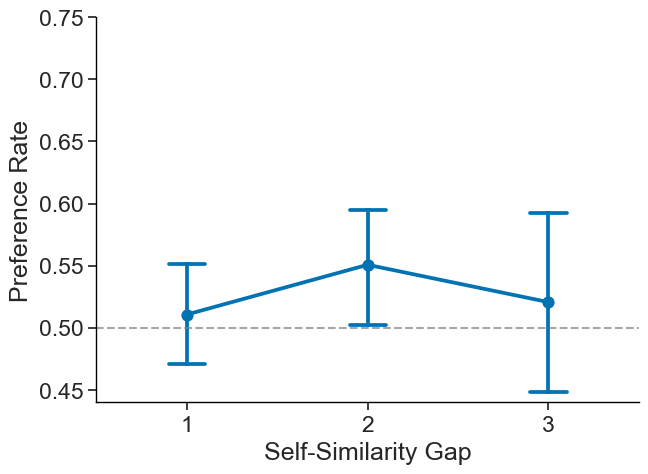

In [3]:
# Create output directory if it doesn't exist
os.makedirs("attribute_figures", exist_ok=True)

# Use a color-blind-friendly theme and adjust font sizes
sns.set_theme(
    style="ticks", 
    font_scale=1.5, 
    rc={"axes.linewidth": 1, "axes.edgecolor": "black"}
)
sns.set_palette("colorblind")

plt.figure(figsize=(7, 5))

sns.pointplot(
    data=df,
    x="simDiff",
    y="chosen",
    errorbar=("ci", 95),  # 95% confidence intervals
    capsize=0.2
)

# plt.title("Probability of Preferring the More-Similar Player", pad=14)
plt.xlabel("Self-Similarity Gap")
plt.ylabel("Preference Rate")

# Add a dashed line at 0.5 to indicate 'chance level'
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)

# Give the y-axis a bit more space around the data
plt.ylim(0.44, 0.75)

# Remove the top and right spines for a cleaner look
sns.despine()

# Save figure
fig_path = os.path.join("attribute_figures", "pointplot_chosen_vs_simDiff.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight")
print(f"Plot saved to {fig_path}")

plt.show()

**Interpretation**  
- If the line slopes upward with `simDiff`, participants become more likely
  to pick the more self-similar character (charA) as the gap increases.
- The dashed reference line (y=0.5) indicates no preference overall.

## 3. Produce a Markdown Table of Mean ± 95% CI by simDiff

We mimic a **bootstrap** approach to get approximate CIs for each simDiff group.
Feel free to replace with binomial proportion CIs or your own approach.

In [4]:

grouped = df.groupby("simDiff")["chosen"]

rows = []
for simdiff, subset in grouped:
    mean_val, ci_lower, ci_upper = bootstrap_ci(subset, n_boot=5000, ci=95)
    rows.append({
        "simDiff": simdiff,
        "mean": mean_val,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    })

df_table = pd.DataFrame(rows).sort_values("simDiff").reset_index(drop=True)
df_table

,simDiff,mean,ci_lower,ci_upper
0,1,0.510638,0.471125,0.548632
1,2,0.550691,0.504608,0.596774
2,3,0.520619,0.453608,0.592784


In [5]:

# Ensure the 'tables' directory exists
os.makedirs("tables", exist_ok=True)

table_filename = os.path.join("tables", "table_chosen_vs_simDiff.md")

with open(table_filename, "w", encoding="utf-8") as f:
    # Write the table header row (column names):
    f.write("| Self-Similarity Gap | Preference Rate | 95% CI (Lower) | 95% CI (Upper) |\n")
    f.write("|:-----------------------:|:------------------------:|---------------:|---------------:|\n")

    # Write each row, using the numeric data
    for _, row in df_table.iterrows():
        surplus_str = str(int(row["simDiff"]))  
        mean_str = f"{row['mean']:.3f}"
        ci_low_str = f"{row['ci_lower']:.3f}"
        ci_high_str = f"{row['ci_upper']:.3f}"
        
        f.write(f"| {surplus_str} | {mean_str} | {ci_low_str} | {ci_high_str} |\n")

    # Now add the caption after the table with Quarto's syntax:
    f.write("\n")
    f.write(": Probability of preferring the more self-similar player as a function of self-similarity gap. {#tbl-selection}\n")

with open(table_filename, "r", encoding="utf-8") as f:
    table = f.read()

print(table)

| Self-Similarity Gap | Preference Rate | 95% CI (Lower) | 95% CI (Upper) |
|:-----------------------:|:------------------------:|---------------:|---------------:|
| 1 | 0.511 | 0.471 | 0.549 |
| 2 | 0.551 | 0.505 | 0.597 |
| 3 | 0.521 | 0.454 | 0.593 |

: Probability of preferring the more self-similar player as a function of self-similarity gap. {#tbl-selection}



**Done!**  

The file [**table_chosen_vs_simDiff.md**](./markdown/table_chosen_vs_simDiff.md)
now contains a row per `simDiff`, with mean Preference Rate and approximate 
95% CIs from the bootstrap approach.